# Titanic


## Resumo de que foi feito

Tentei aplicar todos os conceitos ensinados no curso e aplicar eles no dataset Titanic. Primeiro importei os dataset, para não ter que baixar ele, carreguei ele direto do site.  

Reutilizei a maioria das funções que estavam nos notebooks do curso.

| Conceito | Notebook |
|---|---|
| Carregamento e limpeza | — |
| Regressão Linear (Fare ~ Age) | `LinearRegression.ipynb` |
| Regressão Polinomial e overfitting | `PolynomialRegression.ipynb` e `TrainTest.ipynb` |
| Regressão Múltipla (Fare ~ várias features) | `MultipleRegression.ipynb` |
| Árvore de Decisão e Random Forest | `DecisionTree.ipynb` |
| XGBoost | `XGBoost.ipynb` |
| K-Means Clustering | `KMeans.ipynb` |
| SVM | `SVC.ipynb` |
| Naive Bayes nos títulos dos nomes | `NaiveBayes.ipynb` |

## Carregamento do dataset

In [34]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import *

# Dataset do titanic
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Primeiro, vou verificar o formato do dataset e onde tem valores nulos.

In [35]:
print("Shape:", df.shape)
print("\nValores nulos:\n\n", df.isnull().sum())

Shape: (891, 12)

Valores nulos:

 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


O scikit-learn exige que tudo seja numérico, então usei `.map()` para as variáveis categóricas virarem variáveis numéricas.

In [36]:
# Preenche os valores NaN com a mediana
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
# Preeche os valores Nan com a moda
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Mapeia a coluna de valores categóricos com valores numéricos
d = {'male': 0, 'female': 1}
df['Sex'] = df['Sex'].map(d)
d = {'S': 0, 'C': 1, 'Q': 2}
df['Embarked'] = df['Embarked'].map(d)

# Calcula o tamanho da família
df['FamilySize'] = df['SibSp'] + df['Parch']

# Mostrar quantos dados nulos existem ainda
print("Nulos restantes:", df.isnull().sum().sum())
df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']].head()

Nulos restantes: 687


C:\Users\Edryck\AppData\Local\Temp\ipykernel_11996\930179111.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Edryck\AppData\Local\Temp\ipykernel_11996\930179111.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,0,22.0,7.2500,0,1
1,1,1,1,38.0,71.2833,1,1
2,1,3,1,26.0,7.9250,0,0
3,1,1,1,35.0,53.1000,0,1
4,0,3,0,35.0,8.0500,0,0


Agora, usei a regressão linear para ver se a idade da pessoa tem alguma relação linear com a tarifa (age -> fare)

In [40]:
from scipy import stats

# Pega os valores referentes a idade e tarifa
x_age = df['Age'].values
y_fare = df['Fare'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x_age, y_fare)

print(f"R^2: {r_value**2:.4f}")
print(f"Slope: {slope:.4f} | Intercept: {intercept:.4f}")

R^2: 0.0093
Slope: 0.3690 | Intercept: 21.3686


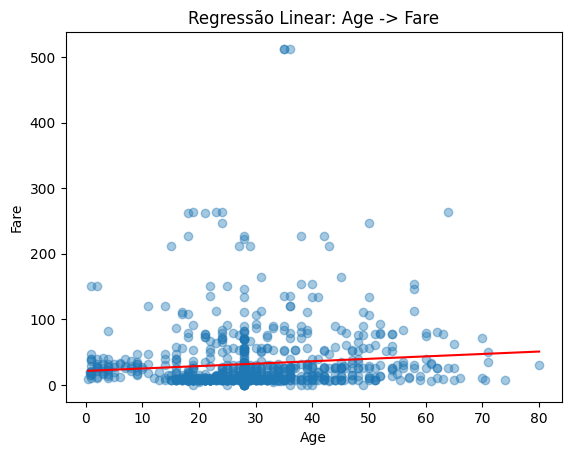

In [41]:
# Mesma função predict() da aula de regressão linear
def predict(x):
    return slope * x + intercept

fitLine = predict(x_age)

# Plota um gráfico de dispersão
plt.scatter(x_age, y_fare, alpha=0.4)
plt.plot(sorted(x_age), predict(np.array(sorted(x_age))), c='r')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Regressão Linear: Age -> Fare')
plt.show()

O R² baixo era esperado já que a tarifa depende mais da classe do que da idade.  
Isso mostra que a relação de idade com tarifa não é linear, então vou usar regressão polinomial para conseguir capturar melhor a relação. Vou usar o `np.polyfit`, igual como foi feito na aula 2 de Machine Learning with Python, com graus diferentes e avaliar o conjunto de teste para encontrar algum overfitting. Estarei reutilizando o código da aula de regressão polinomial e prevenção de overfitting usando treino/teste.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x = np.array(df['Age'])
y = np.array(df['Fare'])

# Train/test split, mesma ideia da aula de prevenção de overfitting usando treino/teste, só que usando sklearn
trainX, testX, trainY, testY = train_test_split(x, y, test_size=0.2, random_state=42)

# Mostra a quantidade de treino e testes
print(f"Treino: {len(trainX)}\nTeste: {len(testX)}")

Treino: 712
Teste: 179


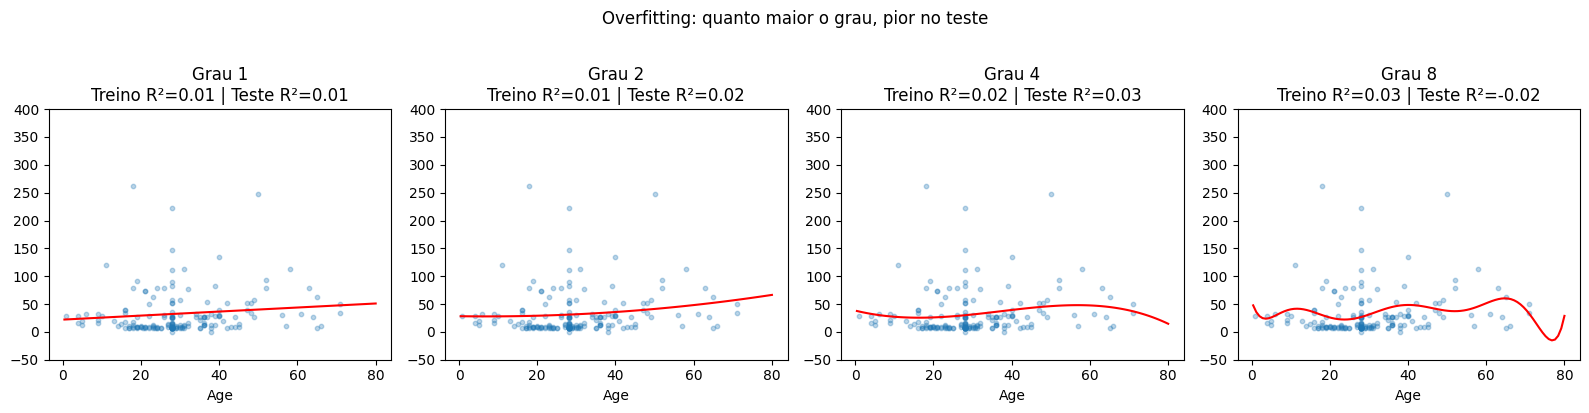

In [44]:
# Testar diferentes graus
xp = np.linspace(x.min(), x.max(), 100)

# Cria sub gráficos
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
graus = [1, 2, 4, 8]

# Faz para cada grau
for ax, grau in zip(axes, graus):
    p = np.poly1d(np.polyfit(trainX, trainY, grau))
    r2_train = r2_score(trainY, p(trainX))
    r2_test  = r2_score(testY,  p(testX))
    ax.scatter(testX, testY, alpha=0.3, s=10)
    ax.plot(xp, p(xp), c='r')
    ax.set_ylim(-50, 400)
    ax.set_title(f'Grau {grau}\nTreino R²={r2_train:.2f} | Teste R²={r2_test:.2f}')
    ax.set_xlabel('Age')

# Mostra os gráficos
plt.suptitle('Overfitting: quanto maior o grau, pior no teste', y=1.02)
plt.tight_layout()
plt.show()

Como observado nos gráficos anteriores, quanto maior os grau, maior overfitting.  
Agora vou usar a regressão múltipla, com múltiplas features, os coeficientes vão mostrar quais variáveis vai influenciar mais na tarifa.

In [45]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

X = df[['Pclass', 'Age', 'FamilySize']].copy()
y = df['Fare']

# Escalar — igual ao MultipleRegression.ipynb
X[['Pclass', 'Age', 'FamilySize']] = scale.fit_transform(X[['Pclass', 'Age', 'FamilySize']].values)

# Adicionar constante para o intercepto — igual ao MultipleRegression.ipynb
X = sm.add_constant(X)

est = sm.OLS(y, X).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                   Fare   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     172.0
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           7.04e-88
Time:                        12:00:03   Log-Likelihood:                -4539.6
No. Observations:                 891   AIC:                             9087.
Df Residuals:                     887   BIC:                             9106.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.2042      1.326     24.287      0.0

In [46]:
# Fazer uma previsão de tarifa
# Exexmplo, passageiro de primeira classe, idade de 30 anos e viajando sozinho
scaled = scale.transform([[1, 30, 0]])
# Adiciona a constante
scaled = np.insert(scaled[0], 0, 1)
predicted = est.predict(scaled)
print(f"Tarifa prevista para 1ª classe, 30 anos, sem família: £{predicted[0]:.2f}")

# Passageiro de terceira classe, com 30 anos e viajando sozinho
scaled2 = scale.transform([[3, 30, 0]])
# Adiciona a constante
scaled2 = np.insert(scaled2[0], 0, 1)
predicted2 = est.predict(scaled2)
print(f"Tarifa prevista para 3ª classe, 30 anos, sem família: £{predicted2[0]:.2f}")

Tarifa prevista para 1ª classe, 30 anos, sem família: £70.32
Tarifa prevista para 3ª classe, 30 anos, sem família: £1.46


Agora, vou usar a árvore para ler as regras, dessa forma vai ser mais fácil de interpretar. A random forest vai mostrar como o ensemble reduz a variância.

In [49]:
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Features, mesma lista de colunas na aula 12 do tópico Machine Learning with Python
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']

X = df[features]
y = df['Survived']

# Aqui usei Train/test split das aulas do XGBoost (aula 14) e TrainTest (aula 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Árvore de Decisão, igual ao DecisionTree da aula 12
clf = tree.DecisionTreeClassifier(max_depth=4)
clf = clf.fit(X_train, y_train)

print("Acurácia (Árvore de Decisão):", accuracy_score(y_test, clf.predict(X_test)))

Acurácia (Árvore de Decisão): 0.8156424581005587


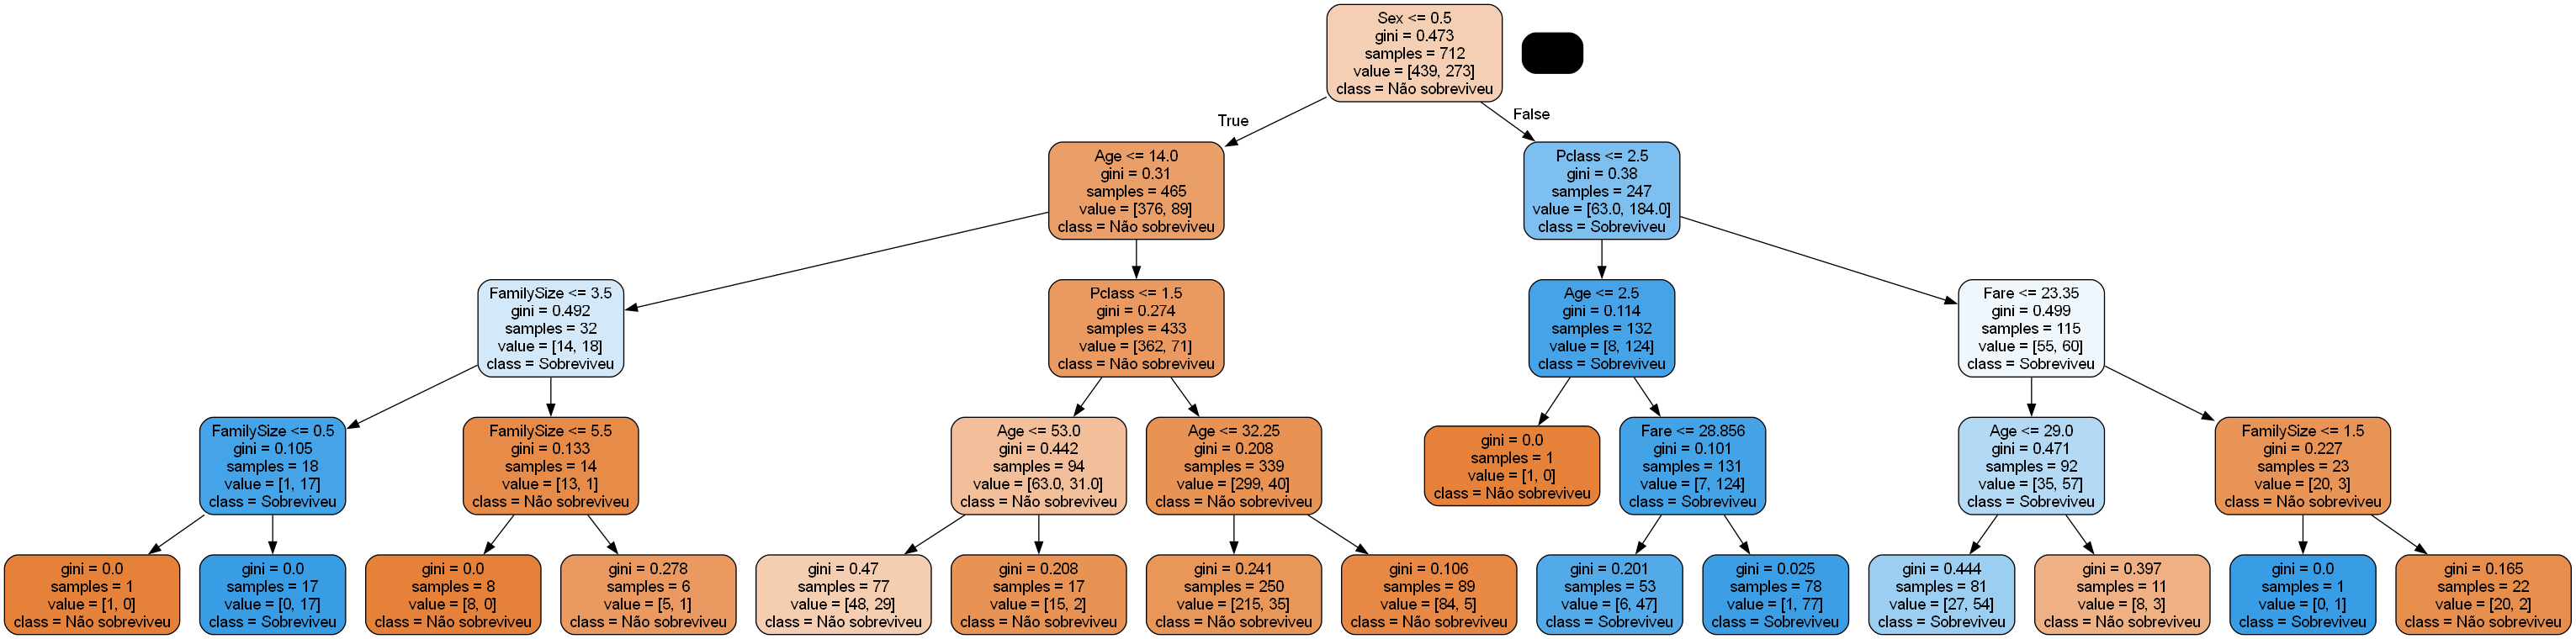

In [48]:
# Visualizar a árvore, igual ao DecisionTree da aula 12 (precisa do graphviz instalado)
from IPython.display import Image
from io import StringIO
import pydotplus

dot_data = StringIO()
tree.export_graphviz(clf, out_file=dot_data, feature_names=features,
                     class_names=['Não sobreviveu', 'Sobreviveu'],
                     filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [58]:
# Random Forest, igual ao DecisionTree (seção Ensemble Learning)
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf = rf.fit(X_train, y_train)

print("Acurácia (Random Forest):", accuracy_score(y_test, rf.predict(X_test)))

# Previsão para perfis específicos, igual ao DecisionTree
# Pclass = 1, Sex = female, Age = 25, Fare = 100, Embarked = S, FamilySize = 1
print("Mulher, 1ª classe, 25 anos:", rf.predict([[1, 1, 25, 100, 0, 1]]))

# Pclass = 3, Sex = male, Age = 25, Fare = 8, Embarked = S, FamilySize = 0
print("Homem, 3ª classe, 25 anos:", rf.predict([[3, 0, 25, 8, 0, 0]]))

Acurácia (Random Forest): 0.8212290502793296
Mulher, 1ª classe, 25 anos: [1]
Homem, 3ª classe, 25 anos: [0]


C:\Users\Edryck\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Edryck\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Usei a mesma estrutura da aula XGBoost (aula 14) para comparar o boosting, que corrige erros de forma sequencial, contra o bagging do Random Forest no mesmo problema. 

---
## 6. XGBoost: prever Survived

Mesma estrutura do `XGBoost.ipynb`:  
`xgb.DMatrix` → `param` dict → `xgb.train` → `model.predict` → `accuracy_score`.

In [62]:
import xgboost as xgb

# Converter para DMatrix, igual o XGBoost (aula 14)
train = xgb.DMatrix(X_train, label=y_train)
test  = xgb.DMatrix(X_test,  label=y_test)

# Hiperparâmetros, segue a mesma estrutura do XGBoost (aula 14)
# binary: logistic porque Survived é 0 ou 1, diferente do Iris que era multiclasse
param = {
    'max_depth': 4,
    'eta': 0.3,
    'objective': 'binary:logistic',
}
epochs = 10

model_xgb = xgb.train(param, train, epochs)

# predict retorna probabilidades, convertemos para 0 ou 1
predictions = (model_xgb.predict(test) >= 0.5).astype(int)

print("Acurácia (XGBoost):", accuracy_score(y_test, predictions))

Acurácia (XGBoost): 0.8379888268156425


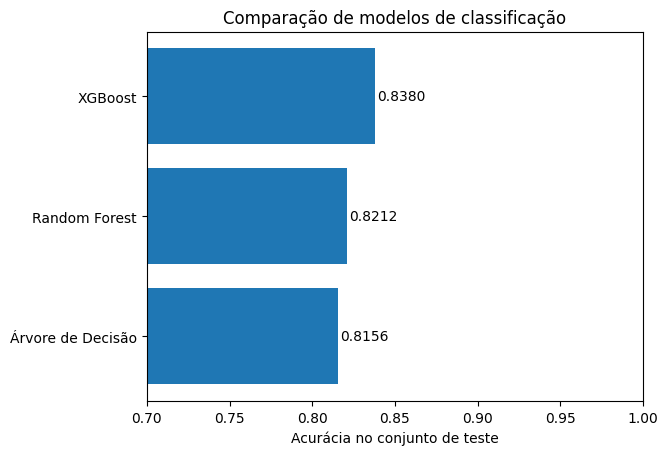

In [65]:
# Comparação dos três modelos de classificação
modelos = {
    'Árvore de Decisão': accuracy_score(y_test, clf.predict(X_test)),
    'Random Forest':     accuracy_score(y_test, rf.predict(X_test)),
    'XGBoost':           accuracy_score(y_test, predictions),
}

plt.barh(list(modelos.keys()), list(modelos.values()))
plt.xlim(0.7, 1.0)
plt.xlabel('Acurácia no conjunto de teste')
plt.title('Comparação de modelos de classificação')
for i, (k, v) in enumerate(modelos.items()):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')
plt.show()

Todos os outros três modelos eram supervisionados, agora vou usar o K-Means, ele é o único modelo não supervisionado, ele agrupa passageiros por perfil sem saber quem sobreviveu e depois ele compara visualmente com a realidade. Segui a estrutura do que foi mostrado na aula do K-Means (aula 06).  
Aqui usei K-Means sem a coluna `Survived`, aprendizado não supervisionado.  
Depois pintei os pontos por sobrevivência real para ver se os clusters coincidem.

In [71]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale

# Dados para clustering: Age, Fare, Pclass, sem Survived
data_cluster = df[['Age', 'Fare', 'Pclass']].values

# Escalar, é essencial para resultados bons, é uma nota da aula
model_km = KMeans(n_clusters=3, random_state=42, n_init=10)
model_km = model_km.fit(scale(data_cluster))

print("Labels encontrados:", np.unique(model_km.labels_))

Labels encontrados: [0 1 2]


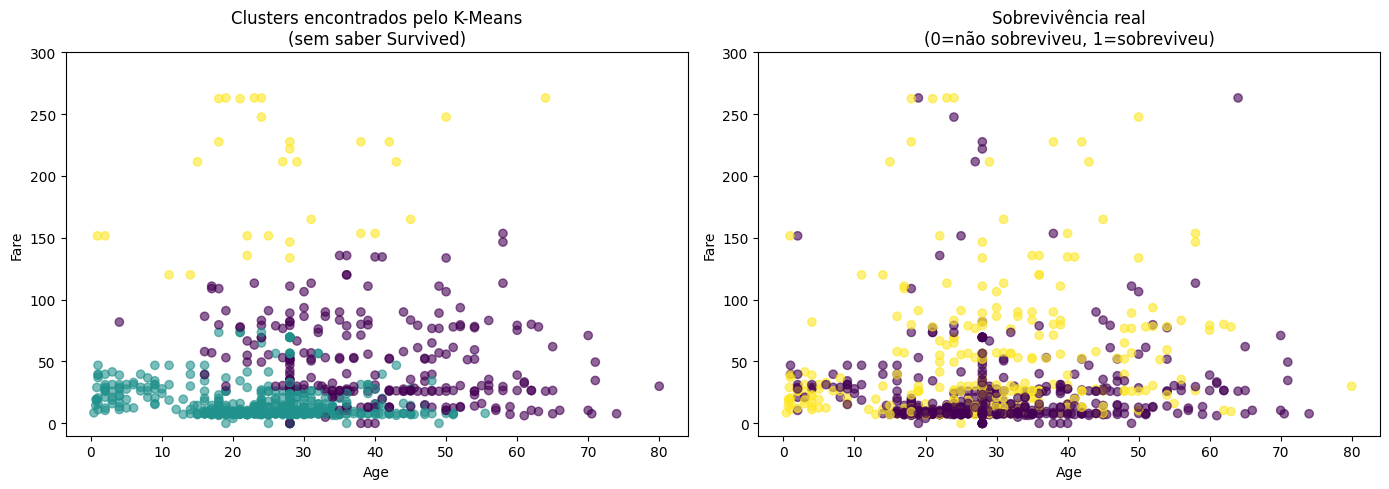

In [74]:
# Visualizar clusters vs sobrevivência real, mesma lógica de scatter do KMeans (aula 06)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Clusters encontrados pelo K-Means
ax1.scatter(x=df['Age'], y=df['Fare'],
            c=model_km.labels_.astype(float), cmap='viridis', alpha=0.6)
ax1.set_xlabel('Age')
ax1.set_ylabel('Fare')
ax1.set_ylim(-10, 300)
ax1.set_title('Clusters encontrados pelo K-Means\n(sem saber Survived)')

# Sobrevivência real
ax2.scatter(x=df['Age'], y=df['Fare'],
            c=df['Survived'].astype(float), cmap='viridis', alpha=0.6)
ax2.set_xlabel('Age')
ax2.set_ylabel('Fare')
ax2.set_ylim(-10, 300)
ax2.set_title('Sobrevivência real\n(0=não sobreviveu, 1=sobreviveu)')

plt.tight_layout()
plt.show()

Mostra como kernels diferentes traçam fronteiras de decisão distintas no mesmo espaço bidimensional (aula 16).

In [79]:
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler

X_svm = df[['Age', 'Fare']].values
y_svm = df['Survived'].values

# Escalar com MinMaxScaler — igual ao SVC.ipynb
scaling = MinMaxScaler(feature_range=(-1, 1)).fit(X_svm)
X_svm_scaled = scaling.transform(X_svm)

# SVC linear, como mostrado na aula
C = 1.0
svc_linear = svm.SVC(kernel='linear', C=C).fit(X_svm_scaled, y_svm)
svc_rbf    = svm.SVC(kernel='rbf',    C=C).fit(X_svm_scaled, y_svm)

print("Acurácia SVM linear:", accuracy_score(y_svm, svc_linear.predict(X_svm_scaled)))
print("Acurácia SVM RBF:   ", accuracy_score(y_svm, svc_rbf.predict(X_svm_scaled)))

Acurácia SVM linear: 0.6621773288439955
Acurácia SVM RBF:    0.6936026936026936


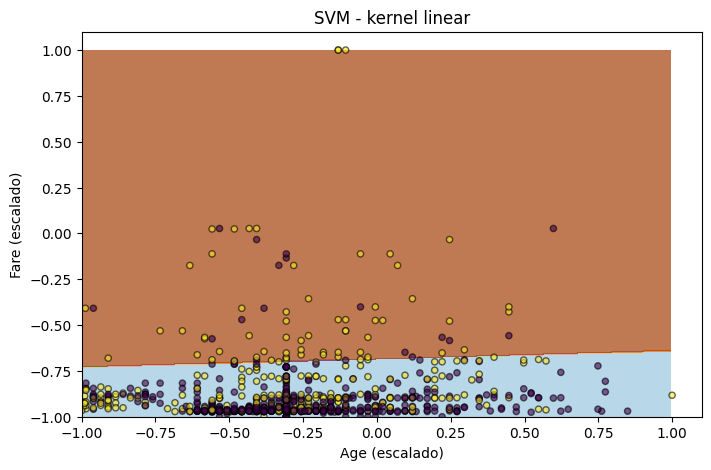

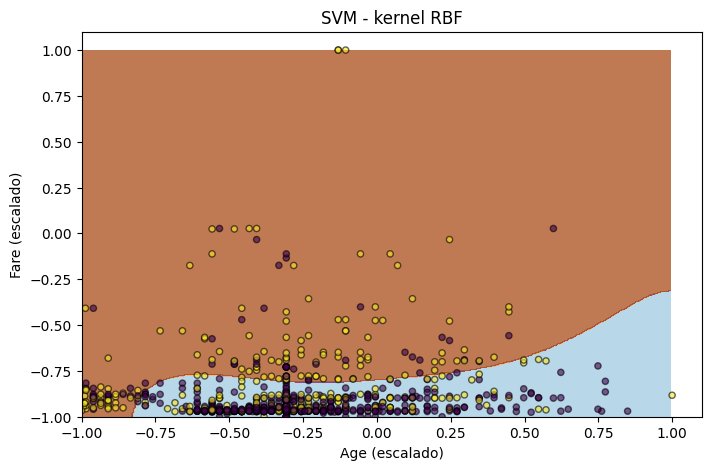

In [82]:
# plotPredictions, reutilizei a função retirada diretamente do notebook da aula 16
def plotPredictions(clf, title):
    xx, yy = np.meshgrid(np.arange(-1, 1, .005),
                         np.arange(-1, 1, .005))
    npx = xx.ravel()
    npy = yy.ravel()
    samplePoints = np.c_[npx, npy]
    Z = clf.predict(samplePoints)
    plt.figure(figsize=(8, 5))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(X_svm_scaled[:, 0], X_svm_scaled[:, 1],
                c=y_svm.astype(float), edgecolors='k', s=20, alpha=0.6)
    plt.xlabel('Age (escalado)')
    plt.ylabel('Fare (escalado)')
    plt.title(title)
    plt.show()

plotPredictions(svc_linear, 'SVM - kernel linear')
plotPredictions(svc_rbf,    'SVM - kernel RBF')

In [84]:
# Agora uma previsão para um ponto específico, como na aula 16 - SVC
# Mulher jovem, tarifa alta (primeira classe)
print("Mulher jovem, tarifa alta:", svc_rbf.predict(scaling.transform([[22, 200]])))

# Homem velho, tarifa baixa (terceira classe)
print("Homem mais velho, tarifa baixa:", svc_rbf.predict(scaling.transform([[55, 8]])))

Mulher jovem, tarifa alta: [1]
Homem mais velho, tarifa baixa: [0]


Para finalizar, agora fazer com o único modelo orientado a texto, os títulos (Mr, Mrs, Miss, Master) carregam informação de gênero/idade/status que prediz sobrevivência, vou usar Naive Bayes para classificar pelo título do nome.  
O campo `Name` do Titanic contém títulos como *Mr*, *Mrs*, *Miss*, *Master*, *Dr*, *Rev*, então usei isso como feature de texto para prever sobrevivência.

In [87]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Usar o campo Name como 'mensagem', segue a mesma ideia do NaiveBayes da aula 4
names = df['Name'].values
targets = df['Survived'].values

# CountVectorizer, usei igual ao NaiveBayes da aula 4
vectorizer = CountVectorizer()
counts = vectorizer.fit_transform(names)

classifier = MultinomialNB()
classifier.fit(counts, targets)

print("Acurácia (Naive Bayes nos nomes):",
      accuracy_score(targets, classifier.predict(counts)))

Acurácia (Naive Bayes nos nomes): 0.9057239057239057


In [98]:
# Testar usando a mesma abordagem do NaiveBayes da aula 4
exemplos = [
    'Miss. Anna Smith', # mulher jovem solteira
    'Mr. John Jones', # homem adulto
    'Mrs. Mary Brown', # mulher casada
    'Master. James Taylor', # criança do sexo masculino
    'Dr. Robert Wilson', # médico ou doutor
]

example_counts = vectorizer.transform(exemplos)
predictions_nb = classifier.predict(example_counts)

for nome, pred in zip(exemplos, predictions_nb):
    resultado = 'Sobreviveu' if pred == 1 else 'Não sobreviveu'
    print(f"{nome} - {resultado}")

Miss. Anna Smith - Sobreviveu
Mr. John Jones - Não sobreviveu
Mrs. Mary Brown - Sobreviveu
Master. James Taylor - Sobreviveu
Dr. Robert Wilson - Sobreviveu


In [102]:
# Aplicando train/test ao Naive Bayes, essa foi a atividade sugerida no NaiveBayes da aula 4
counts_train, counts_test, y_nb_train, y_nb_test = train_test_split(
    counts, targets, test_size=0.2, random_state=42
)

classifier_tt = MultinomialNB()
classifier_tt.fit(counts_train, y_nb_train)

print("Acurácia Naive Bayes (train):",
      accuracy_score(y_nb_train, classifier_tt.predict(counts_train)))
print("Acurácia Naive Bayes (test): ",
      accuracy_score(y_nb_test,  classifier_tt.predict(counts_test)))

Acurácia Naive Bayes (train): 0.9115168539325843
Acurácia Naive Bayes (test):  0.7932960893854749


## Finalizando

| Tarefa | Modelo | Métrica usada |
|---|---|---|
| Fare ~ Age | Regressão Linear | R² (baixo - relação fraca) |
| Fare ~ Age (graus 1-8) | Regressão Polinomial | R² treino vs teste - overfitting visível no grau 8 |
| Fare ~ Pclass+Age+FamilySize | Regressão Múltipla | Coeficientes OLS - Pclass é o mais relevante |
| Survived | Árvore de Decisão | Acurácia |
| Survived | Random Forest | Acurácia |
| Survived | XGBoost | Acurácia |
| Perfis (sem Survived) | K-Means (k=3) | Clusters comparados com sobrevivência real |
| Survived | SVM linear e RBF | Acurácia + regiões de decisão |
| Survived (pelo nome) | Naive Bayes | Acurácia treino/teste |